## Parte 02 - Auditoria do Modelo em Produção

Este notebook audita o desempenho do **Modelo A**, atualmente em produção, usando a base rotulada de chamados da Central 1746. A análise responde duas perguntas práticas:

> 1. O desempenho global e por categoria é bom o suficiente quando consideramos incerteza estatística?

> 2. Os erros estão distribuídos de forma homogênea ou aparecem concentrados em categorias, textos e subgrupos específicos?

A análise exploratória concluiu que a base é desbalanceada em `categoria_real`. Por isso, a acurácia é tratada como uma medida descritiva, enquanto métricas como **F1 Macro, Recall Macro, Kappa de Cohen e Coeficiente de Matthews** receberão maior peso interpretativo.

Também avaliamos a confiança declarada em `conf_modelo_a`, padrões da matriz de confusão entre `categoria_real` e `pred_modelo_a`, testes de homogeneidade dos erros e um modelo logístico auxiliar para estimar fatores associados à probabilidade de erro. A auditoria usa três blocos de evidência complementares:

- **Desempenho com incerteza:** métricas globais com intervalos de confiança via bootstrap estratificado por `categoria_real` e métricas por categoria com intervalos de Wilson ou bootstrap.
- **Diagnóstico de falhas:** matriz de confusão, erros de alta confiança e comparação da taxa de erro entre subgrupos.
- **Modelagem auxiliar dos erros:** regressão logística binomial para estimar a associação entre `erro_modelo_a` e fatores como `categoria_real`, `canal`, `faixa_tamanho_texto` e `log_palavras`.\
‎ 

---
---

### **Importação de Pacotes, Configuração e Leitura dos Dados**

**Objetivo:** carregar bibliotecas, funções auxiliares e parâmetros usados na auditoria do [pred_modelo_a].

**Importância:** manter a configuração centralizada reduz inconsistências entre tabelas, gráficos, intervalos de confiança e arquivos exportados.

---

In [1]:
# Importa bibliotecas de manipulação, visualização, estatística e avaliação de classificadores
from pathlib import Path
from typing import Any, Dict, Optional, Sequence, Tuple, Union
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

from scipy.stats import chi2_contingency
from statsmodels.stats.proportion import proportion_confint
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.metrics import confusion_matrix, f1_score

from IPython.display import display
from functions import (
    pretty_label,
    save_figure,
    save_table,
    load_and_prepare_data,
    calcular_metricas_globais,
    gerar_amostra_bootstrap_estratificada,
)
# Evita que avisos de bibliotecas poluam a leitura do notebook
warnings.filterwarnings("ignore")

In [2]:
# Define tema visual, resolução das figuras e diretórios de saída.
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 180
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

output_dir = Path("../results")
fig_dir = output_dir / "figures/auditoria_modelo_a"
tab_dir = output_dir / "tables/auditoria_modelo_a"

# Cria diretórios caso ainda não existam, permitindo exportar gráficos e tabelas.
fig_dir.mkdir(parents=True, exist_ok=True)
tab_dir.mkdir(parents=True, exist_ok=True)

In [3]:
# Carrega a base e aplica os tratamentos padronizados definidos no projeto.
path = Path("../dados/chamados_com_predicoes.csv")
df = load_and_prepare_data(path)

# Define parâmetros globais de inferência usados nos intervalos de confiança.
n_bootstrap = 1000
seed = 42
alpha = 0.05

In [4]:
# Padroniza a predição do Modelo A e cria indicadores binários de acerto e erro
df["pred_modelo_a"] = df["pred_modelo_a"].astype(str).str.strip()
df["acerto_modelo_a"] = df["pred_modelo_a"] == df["categoria_real"]
df["erro_modelo_a"] = ~df["acerto_modelo_a"]
# Usa log(1 + n_palavras) para reduzir assimetria da contagem de palavras
df["log_palavras"] = np.log1p(df["palavra_count"]) 

# Separa os textos em quartis de tamanho para comparar desempenho por comprimento textual
df["faixa_tamanho_texto"] = pd.qcut(
    df["palavra_count"],
    q=4,
    labels=[
        "Textos mais curtos",
        "Textos médio-curtos",
        "Textos médio-longos",
        "Textos mais longos",
    ],duplicates="drop"
)

# Agrupa a confiança declarada pelo Modelo A em faixas de 10 pontos percentuais
df["faixa_confianca_a"] = pd.cut(
    df["conf_modelo_a"],
    bins=np.linspace(0, 1, 11),
    include_lowest=True
)

# Ordena as classes por frequência real para manter tabelas e gráficos consistentes
classes = df["categoria_real"].value_counts().sort_values(ascending=False).index.tolist()

- Foram criadas as colunas `acerto_modelo_a` e `erro_modelo_a`, que são a base da auditoria.

- A variável `faixa_tamanho_texto` permite avaliar se textos curtos, médios ou longos afetam a chance de erro. Isso é importante porque textos com pouca informação podem ser mais ambíguos para classificação.

- A variável `faixa_confianca_a` permite analisar se a confiança declarada pelo modelo acompanha a acurácia observada. \
Esse ponto é crítico caso `conf_modelo_a` seja usada para automatizar decisões sem revisão humana.

---
---
### **1. Desempenho com Incerteza**
---
---

#### **1.1 Desempenho Global do Modelo com Bootstrap**

**Objetivo:** estimar o desempenho global do Modelo A em `categoria_real` versus `pred_modelo_a`, reportando intervalos de confiança de 95%.

**Metodologia:** usamos bootstrap estratificado por `categoria_real`. 

Em cada repetição $b$, os chamados são reamostrados com reposição dentro de cada categoria, preservando o desbalanceamento original da base.\
Para cada métrica $m$, obtemos uma distribuição $\{\hat{m}^{(1)}, \ldots, \hat{m}^{(B)}\}$. O IC 95% é dado pelos percentis 2,5% e 97,5% dessa distribuição.

**Importância:** em uma base desbalanceada, acurácia pode mascarar desempenho ruim em categorias menores. \
Por isso, Recall Macro (acurácia balanceada) (1), F1 Macro (2), Kappa de Cohen (3) e Coeficiente de Matthews (4) ajudam a avaliar o modelo sem deixar as classes majoritárias dominarem a conclusão.

$$\text{Recall Macro} = \frac{1}{K} \sum_{k=1}^K  \text{Recall}_k =\sum_{k=1}^K \frac{TP_k}{TP_k +FN_k} \quad (1)$$
$$\text{F1 Macro} = \frac{1}{K} \sum_{k=1}^K \text{F1}_k = 2 \frac{\text{Precisão}_k \cdot \text{Recall}_k}{\text{Precisão}_k + \text{Recall}_k} \quad (2)$$

São adequados, porque tratam todas as categorias com o mesmo peso, independentemente do número de chamados.

$$\kappa=\frac{p_o-p_e}{1-p_e} \quad (3)$$

- $p_o$ é a proporção de concordância observada, isto é, a acurácia;
- $p_e$ é a proporção de concordância esperada ao acaso, considerando a distribuição das classes.

O Kappa de Cohen indica:
- $\kappa=1$ : concordância perfeita;
- $\kappa=0$ : concordância equivalente ao acaso;
- $\kappa<0$ : pior do que o acaso.

É adequado porque a acurácia sozinha não considera que, em uma base desbalanceada, parte dos acertos pode acontecer simplesmente porque o modelo favorece categorias mais comuns. O Kappa ajusta a métrica levando em conta esse acerto esperado por acaso.

$$\mathrm{MCC}=\frac{T P \cdot T N-F P \cdot F N}{\sqrt{(T P+F P)(T P+F N)(T N+F P)(T N+F N)}} \quad (4)$$


Em problemas multiclasse, MCC é generalizado a partir da matriz de confusão completa:

- $\mathrm{MCC}=1$ : classificação perfeita;
- $\mathrm{MCC}=0$: desempenho semelhante ao acaso;
- $\mathrm{MCC}=-1$: classificação completamente oposta.

É adequado porque usa a estrutura completa da matriz de confusão. Diferentemente da acurácia, ele considera simultaneamente acertos, falsos positivos e falsos negativos, sendo mais robusto em cenários desbalanceados.

---

In [5]:
# Função para estimar métricas globais e incerteza por bootstrap estratificado.
def bootstrap_metricas_globais(
    df: pd.DataFrame, coluna_real: str = "categoria_real",
    coluna_pred: str = "pred_modelo_a",
    coluna_estrato: str = "categoria_real",
    labels: Optional[Sequence[Any]] = None,
    n_bootstrap: int = 1000,
    alpha: float = 0.05,
    seed: int = 42,
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """Calcula métricas globais e intervalos de confiança via bootstrap estratificado.
    A estratificação preserva a distribuição de [categoria_real] em cada reamostragem.
    """
    rng = np.random.default_rng(seed)

    # Calcula as métricas pontuais na base observada.
    metricas_ponto = calcular_metricas_globais(
        df[coluna_real],
        df[coluna_pred],
        labels,
    )

    resultados_boot = []
    # Reamostra a base várias vezes para aproximar a distribuição amostral das métricas.
    for _ in range(n_bootstrap):
        amostra = gerar_amostra_bootstrap_estratificada(
            df,
            coluna_estrato=coluna_estrato,
            rng=rng,
        )
        metricas_boot = calcular_metricas_globais(
            amostra[coluna_real],
            amostra[coluna_pred],
            labels,
        )
        resultados_boot.append(metricas_boot)

    boot = pd.DataFrame(resultados_boot)
    tabela = []

    # Usa os percentis da distribuição bootstrap como intervalo de confiança.
    for metrica, valor in metricas_ponto.items():
        tabela.append({
            "Métrica": metrica,
            "Estimativa": valor,
            "IC Inf. (95%)": boot[metrica].quantile(alpha / 2),
            "IC Sup. (95%)": boot[metrica].quantile(1 - alpha / 2),
            "Desvio Bootstrap": boot[metrica].std(),
        })

    return pd.DataFrame(tabela), boot

In [6]:
# Calcula métricas globais do Modelo A com IC 95%.
tabela_metricas_globais_a, bootstrap_global_a = bootstrap_metricas_globais(
    df, labels=classes, n_bootstrap=n_bootstrap, alpha=alpha, seed=seed)

display(tabela_metricas_globais_a)
# Exporta a tabela para auditoria e reprodutibilidade.
save_table(tabela_metricas_globais_a, tab_dir, "05_metricas_globais_modelo_a_com_ic")

,Métrica,Estimativa,IC Inf. (95%),IC Sup. (95%),Desvio Bootstrap
0,Acurácia,0.772800,0.761585,0.784205,0.005741
1,Precisão Macro,0.774338,0.762293,0.786914,0.006309
2,Recall Macro,0.770992,0.757232,0.784578,0.006556
3,F1 Macro,0.770438,0.757629,0.782721,0.006217
4,Precisão Ponderada,0.777637,0.766532,0.789403,0.005707
5,Recall Ponderada,0.772800,0.761585,0.784205,0.005741
6,F1 Ponderada,0.772524,0.761260,0.784059,0.005759
7,Kappa de Cohen,0.732224,0.718749,0.745707,0.006772
8,Coeficiente de Matthews,0.733362,0.719765,0.746989,0.006744


PosixPath('../results/tables/auditoria_modelo_a/05_metricas_globais_modelo_a_com_ic.csv')


**<u>Resultados</u>:**

- O Modelo A apresenta acurácia de **0,7728** com IC 95% **[0,7616; 0,7842]**. Como essa métrica é ponderada pelo volume das classes, ela deve ser lida como desempenho global descritivo.

- O Recall Macro é **0,7710** com IC 95% **[0,7572; 0,7846]**, muito próxima da acurácia simples. Isso sugere que o desempenho médio entre classes não colapsa completamente apesar do desbalanceamento.

- O F1 Macro é **0,7704** com IC 95% **[0,7576; 0,7827]**. Essa métrica é central aqui porque dá peso semelhante às categorias e combina `precisao` e `recall`.

- Kappa de Cohen (**0,7322**) e Coeficiente de Matthews (**0,7334**) indicam concordância/desempenho bem acima do acaso, mas ainda com margem relevante para melhoria operacional.

---


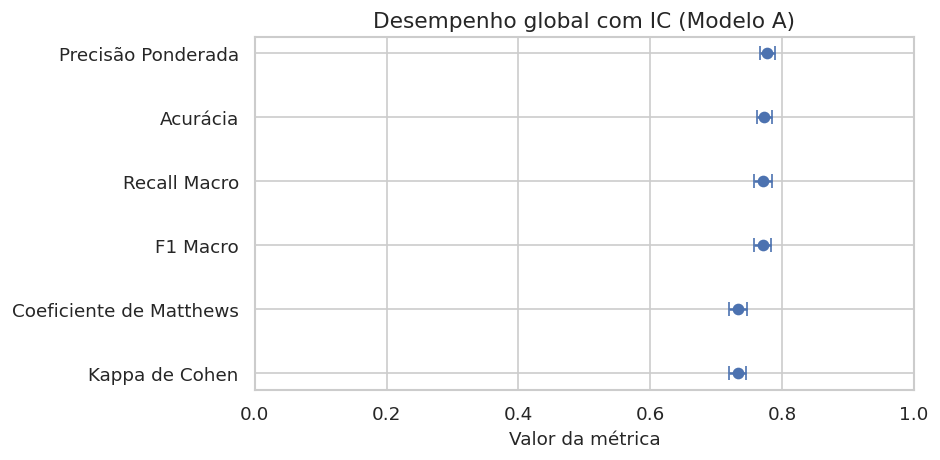

In [7]:
# Seleciona métricas centrais para visualizar estimativas e incerteza em um gráfico compacto.
fig, ax = plt.subplots(figsize=(8, 4))
metricas_plot = tabela_metricas_globais_a[
    tabela_metricas_globais_a["Métrica"].isin([
        "Acurácia",
        "Recall Macro",
        "F1 Macro",
        "Precisão Ponderada",
        "Kappa de Cohen",
        "Coeficiente de Matthews",
    ])
].copy()

metricas_plot = metricas_plot.sort_values("Estimativa")
# Barras horizontais representam a amplitude do IC 95% estimado por bootstrap.
ax.errorbar(
    metricas_plot["Estimativa"],
    metricas_plot["Métrica"],
    xerr=[metricas_plot["Estimativa"] - metricas_plot["IC Inf. (95%)"],
          metricas_plot["IC Sup. (95%)"] - metricas_plot["Estimativa"]],
    fmt="o",
    capsize=4,
)

ax.set_title("Desempenho global com IC (Modelo A)")
ax.set_xlabel("Valor da métrica")
ax.set_ylabel("")
ax.set_xlim(0, 1)
save_figure(fig, fig_dir, "05_metricas_globais_modelo_a_ic")
plt.show()


**<u>Resultado</u>:**

- As barras de incerteza são estreitas nas métricas globais, com desvios bootstrap próximos de **0,006** a **0,007**. Ou seja, com 5.000 chamados, a incerteza global é relativamente pequena.
- As métricas mais robustas ao desbalanceamento ficam concentradas entre **0,73** e **0,77**. O modelo é consistente.
- O Modelo A tem desempenho global razoável, porém a decisão de troca não pode depender apenas desse bloco. É necessário verificar categorias e modos de falha.

---


#### **1.2 Desempenho Estratificado por Categoria**

**Objetivo:** Medir `precisao`, `recall`, `f1` e `taxa_erro` separadamente para cada valor de `categoria_real`.

**Metodologia:** Para cada categoria, avaliamos o problema em formato um-contra-resto. Usamos 
- $\text{precisão}=TP/(TP+FP)$;
- $\text{recall}=TP/(TP+FN)$;
- $\text{F1}=2PR/(P+R)$;
- $\text{taxa de erro}=FN/(TP+FN)$.

`precisao`, `recall` e `taxa_erro` são proporções, então seus intervalos são estimados pelo **Método de Wilson**, mais estável que o intervalo normal simples em categorias menores.\
Como `f1` é uma métrica não linear de `precisao` e `recall], seu intervalo é estimado por bootstrap estratificado.

**Importância:** A decisão de manter ou trocar um classificador não deve depender apenas da média global. \
Em atendimento público, uma categoria com baixo `recall` pode significar muitos chamados encaminhados para o fluxo errado.

---

In [8]:
# Funções para calcular métricas por categoria e seus intervalos de confiança
def intervalo_wilson(sucessos: int, n: int, alpha: float = 0.05) -> Tuple[float, float]:
    """Calcula intervalo de confiança de Wilson para uma proporção binomial."""
    if n == 0:
        return np.nan, np.nan
    
    inferior, superior = proportion_confint(count=sucessos, nobs=n, alpha=alpha, method="wilson")
    return inferior, superior


def calcular_metricas_por_categoria(df: pd.DataFrame, labels: Sequence[Any], alpha: float = 0.05) -> pd.DataFrame:
    """Calcula precisão, recall, F1 e taxa de erro por categoria.
    Usa IC de Wilson para proporções associadas a TP, FP e FN.
    """
    total_erros = df["erro_modelo_a"].sum()
    linhas = []

    for classe in labels:
        # Constrói máscaras binárias para a classe avaliada no esquema um-contra-resto
        real = df["categoria_real"].eq(classe)
        pred = df["pred_modelo_a"].eq(classe)

        tp = (real & pred).sum()
        fp = (~real & pred).sum()
        fn = (real & ~pred).sum()
        tn = (~real & ~pred).sum()

        sup_real = real.sum()
        sup_pred = pred.sum()

        # Precisão olha para o que foi previsto como a classe; recall olha para o que era realmente da classe
        precisao = tp / sup_pred if sup_pred else np.nan
        recall = tp / sup_real if sup_real else np.nan
        f1 = 2 * precisao * recall / (precisao + recall) if precisao + recall > 0 else np.nan
        taxa_erro = fn / sup_real if sup_real else np.nan

        p_ic = intervalo_wilson(tp, sup_pred, alpha)
        r_ic = intervalo_wilson(tp, sup_real, alpha)
        e_ic = intervalo_wilson(fn, sup_real, alpha)

        linhas.append({
            "categoria": classe,
            "suporte_real": sup_real,
            "suporte_predito": sup_pred,
            "precisao": precisao,
            "precisao_ic95_inf": p_ic[0],
            "precisao_ic95_sup": p_ic[1],
            "recall": recall,
            "recall_ic95_inf": r_ic[0],
            "recall_ic95_sup": r_ic[1],
            "f1": f1,
            "taxa_erro": taxa_erro,
            "taxa_erro_ic95_inf": e_ic[0],
            "taxa_erro_ic95_sup": e_ic[1],
            "participacao_erros_totais": fn / total_erros if total_erros else np.nan,
        })
    return pd.DataFrame(linhas)

def bootstrap_f1_por_categoria(
    df: pd.DataFrame,
    labels: Sequence[Any],
    n_bootstrap: int = 1000,
    alpha: float = 0.05,
    seed: int = 42,
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """Estima IC 95% do F1 por categoria usando bootstrap estratificado.
    O F1 é reestimado em cada amostra no formato um-contra-resto.
    """
    rng = np.random.default_rng(seed)
    linhas = []

    for _ in range(n_bootstrap):
        amostra = gerar_amostra_bootstrap_estratificada(
            df, coluna_estrato="categoria_real", rng=rng)

        for classe in labels:
            # Transforma o problema multiclasses em binário para calcular F1 da classe
            y_true_bin = amostra["categoria_real"] == classe
            y_pred_bin = amostra["pred_modelo_a"] == classe
            f1 = f1_score(y_true_bin, y_pred_bin, zero_division=0)

            linhas.append({
                "categoria": classe,
                "f1_bootstrap": f1,
            })

    boot = pd.DataFrame(linhas)

    # Resume a distribuição bootstrap por categoria
    ci = (
        boot.groupby("categoria")["f1_bootstrap"].agg(
        f1_ic95_inf=lambda x: x.quantile(alpha / 2),
        f1_ic95_sup=lambda x: x.quantile(1 - alpha / 2),
        f1_desvio_bootstrap="std").reset_index()
    )
    
    return ci, boot

In [9]:
# Calcula métricas por categoria e junta o IC bootstrap do F1.
tabela_categoria_a = calcular_metricas_por_categoria(
    df, labels=classes, alpha=alpha)

ic_f1_categoria_a, bootstrap_f1_categoria_a = bootstrap_f1_por_categoria(
    df, labels=classes, n_bootstrap=n_bootstrap, alpha=alpha, seed=seed)

tabela_categoria_a = tabela_categoria_a.merge(
    ic_f1_categoria_a, on="categoria", how="left")

# Ordena pelo suporte real para facilitar a leitura das categorias mais representadas.
tabela_categoria_a = tabela_categoria_a.sort_values("suporte_real", ascending=False)
display(tabela_categoria_a)
save_table(tabela_categoria_a, tab_dir, "05_metricas_por_categoria_modelo_a_com_ic")

,categoria,suporte_real,suporte_predito,precisao,precisao_ic95_inf,precisao_ic95_sup,recall,recall_ic95_inf,recall_ic95_sup,f1,taxa_erro,taxa_erro_ic95_inf,taxa_erro_ic95_sup,participacao_erros_totais,f1_ic95_inf,f1_ic95_sup,f1_desvio_bootstrap
0,iluminacao_publica,1143,1057,0.857143,0.834753,0.876946,0.792651,0.768187,0.815154,0.823636,0.207349,0.184846,0.231813,0.208627,0.807337,0.840397,0.008248
1,buraco_via,908,1117,0.664279,0.636064,0.691369,0.817181,0.790721,0.840968,0.732840,0.182819,0.159032,0.209279,0.146127,0.714423,0.751357,0.009447
2,coleta_lixo,806,798,0.814536,0.786085,0.839974,0.806452,0.777749,0.832247,0.810474,0.193548,0.167753,0.222251,0.137324,0.789886,0.831368,0.010242
3,esgoto_vazamento,621,504,0.712302,0.671291,0.750100,0.578100,0.538894,0.616346,0.638222,0.421900,0.383654,0.461106,0.230634,0.605726,0.671259,0.016312
4,poda_arvore,458,442,0.803167,0.763556,0.837555,0.775109,0.734675,0.810967,0.788889,0.224891,0.189033,0.265325,0.090669,0.759686,0.817978,0.014543
5,estacionamento_irregular,437,451,0.800443,0.761089,0.834723,0.826087,0.787749,0.858742,0.813063,0.173913,0.141258,0.212251,0.066901,0.784350,0.838786,0.014087
6,barulho_perturbacao,400,387,0.801034,0.758386,0.837764,0.775000,0.731573,0.813195,0.787802,0.225000,0.186805,0.268427,0.079225,0.757106,0.817259,0.015127
7,sinalizacao,227,244,0.741803,0.683441,0.792670,0.797357,0.740319,0.844498,0.768577,0.202643,0.155502,0.259681,0.040493,0.729158,0.809345,0.020636


PosixPath('../results/tables/auditoria_modelo_a/05_metricas_por_categoria_modelo_a_com_ic.csv')


**<u>Resultados</u>:**

- A categoria mais frágil é `esgoto_vazamento`:
    - `recall` de **0,58** com IC 95% **[0,53; 0,61]**,
    - `f1` de **0,64** com IC 95% **[0,60; 0,67]** e
    - `taxa_erro` de **0,42**. Ela sozinha responde por **23,1%** dos erros totais.

- `buraco_via` tem `recall` alto (**0,81**), mas `precisao` baixa (**0,66**). Isso indica excesso de chamados previstos como `buraco_via`, com muitos falsos positivos.

- `iluminacao_publica` tem o maior suporte real (**1.143 chamados**) e bom `f1` (**0,82**), mas ainda concentra **20,9%** dos erros totais pelo próprio volume.

- `sinalizacao` tem apenas **227 chamados**, o menor suporte da base. O `f1` é **0,76**, mas seu IC 95% é mais amplo **[0,72; 0,80]**, refletindo maior incerteza por amostra menor.
- `estacionamento_irregular` apresenta o melhor equilíbrio entre `precisao` (**0,80**) e `recall` (**0,82**), com `f1` de **0,81**.



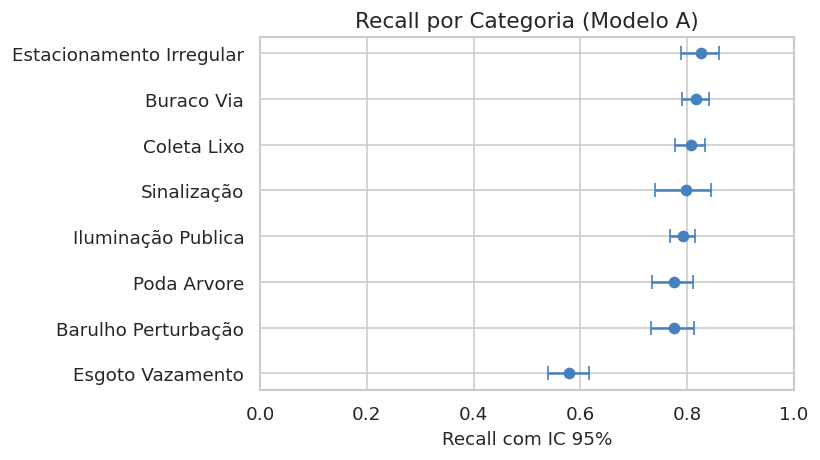

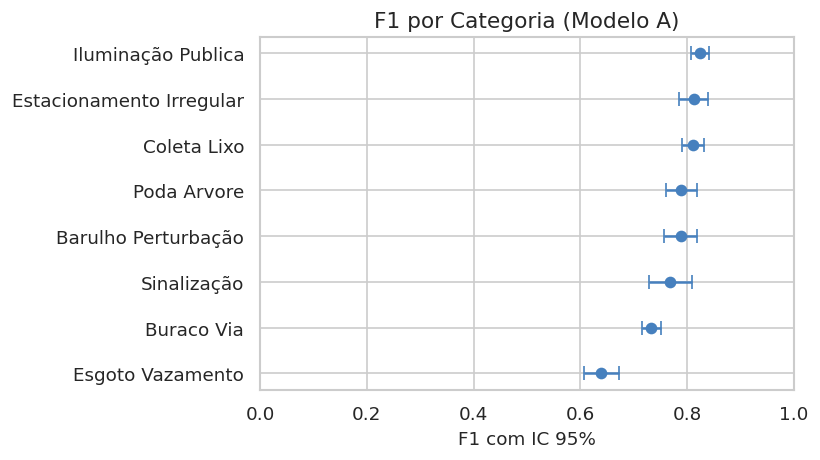

In [10]:
# Função de visualização para comparar métricas por categoria com IC 95%.
def plotar_metrica_categoria(
    tabela: pd.DataFrame,
    metrica: str,
    titulo: str,
    xlabel: str,
    nome_arquivo: str,
) -> None:
    """Plota uma métrica por categoria com intervalo de confiança de 95%."""
    dados = tabela.sort_values(metrica)

    fig, ax = plt.subplots(figsize=(7, 4))
    # Cada ponto é a estimativa da categoria; a barra horizontal é o IC 95%.
    ax.errorbar(
        dados[metrica],
        dados["categoria"].map(pretty_label),
        xerr=[dados[metrica] - dados[f"{metrica}_ic95_inf"],
              dados[f"{metrica}_ic95_sup"] - dados[metrica]],
        fmt="o", capsize=4, color="#4680BE")

    ax.set(title=titulo, xlabel=xlabel, ylabel="", xlim=(0, 1))
    save_figure(fig, fig_dir, nome_arquivo)
    plt.show()


# Compara recall e F1, duas métricas centrais para categorias desbalanceadas.
plotar_metrica_categoria(
    tabela_categoria_a,
    "recall",
    "Recall por Categoria (Modelo A)",
    "Recall com IC 95%",
    "05_recall_por_categoria_modelo_a_ic",
)

plotar_metrica_categoria(
    tabela_categoria_a,
    "f1",
    "F1 por Categoria (Modelo A)",
    "F1 com IC 95%",
    "05_f1_por_categoria_modelo_a_ic",
)


**<u>Resultados</u>:**

- No gráfico de `recall`, `esgoto_vazamento` aparece isolada na pior posição, com valor próximo de **0,58**. Isso confirma que o problema não é apenas ruído pontual da tabela.

- No gráfico de `f1`, `esgoto_vazamento` também fica abaixo das demais categorias, enquanto `iluminacao_publica`, `estacionamento_irregular` e `coleta_lixo` aparecem no topo, próximas ou acima de **0,81**.

- A variação entre categorias mostra que o desempenho do Modelo A não é homogêneo. Uma métrica global de acurácia perto de **0,77** esconde uma categoria com perda operacional bem maior.


#### **1.3 Análise da Confiança do Modelo em Acertos e Erros**

**Objetivo:** verificar se `conf_modelo_a` separa bem predições corretas e incorretas.

**Metodologia:** comparamos média, mediana e quantis de `conf_modelo_a` entre `acerto_modelo_a` verdadeiro e falso. E visualizamos as distribuições por boxplot e densidade.\
Também estimamos uma calibração aproximada usando faixas de confiança e o ECE (Expected Calibration Error), definido como:

$$\text{ECE} = \sum_k w_k \space |\text{confiança média}_k - \text{acurácia observada}_k|$$

em que $w_k$ é o peso da faixa de confiança $k$. Um ECE próximo de 0 indica boa calibração.

**Importância:** se erros recebem confiança tão alta quanto acertos, o score do modelo é pouco útil para triagem automática, revisão humana ou priorização de casos duvidosos.

---

In [11]:
# Função para avaliar calibração aproximada em faixas de confiança
def tabela_calibracao(df: pd.DataFrame, coluna_conf: str = "conf_modelo_a", coluna_acerto: str = "acerto_modelo_a") -> Tuple[pd.DataFrame, float]:
    """Calcula acurácia observada por faixa de confiança e ECE aproximado.
    ECE resume o desvio médio ponderado entre confiança e acurácia.
    """
    tabela = (
        df.groupby("faixa_confianca_a")
        .agg(
            n=("id_chamado", "count"),
            confianca_media=(coluna_conf, "mean"),
            acuracia_observada=(coluna_acerto, "mean")).reset_index()
    )

    # Gap positivo indica confiança média maior do que a acurácia observada
    tabela["gap_calibracao"] = tabela["confianca_media"] - tabela["acuracia_observada"]
    tabela["peso"] = tabela["n"] / tabela["n"].sum()
    # Expected Calibration Error: média ponderada dos gaps absolutos por faixa
    ece = (tabela["peso"] * tabela["gap_calibracao"].abs()).sum()
    return tabela, ece

,acerto_modelo_a,n,confianca_media,confianca_mediana,confianca_p10,confianca_p90,resultado
0,False,1136,0.922631,0.935,0.851,0.976,Erros
1,True,3864,0.922826,0.933,0.854,0.979,Acertos


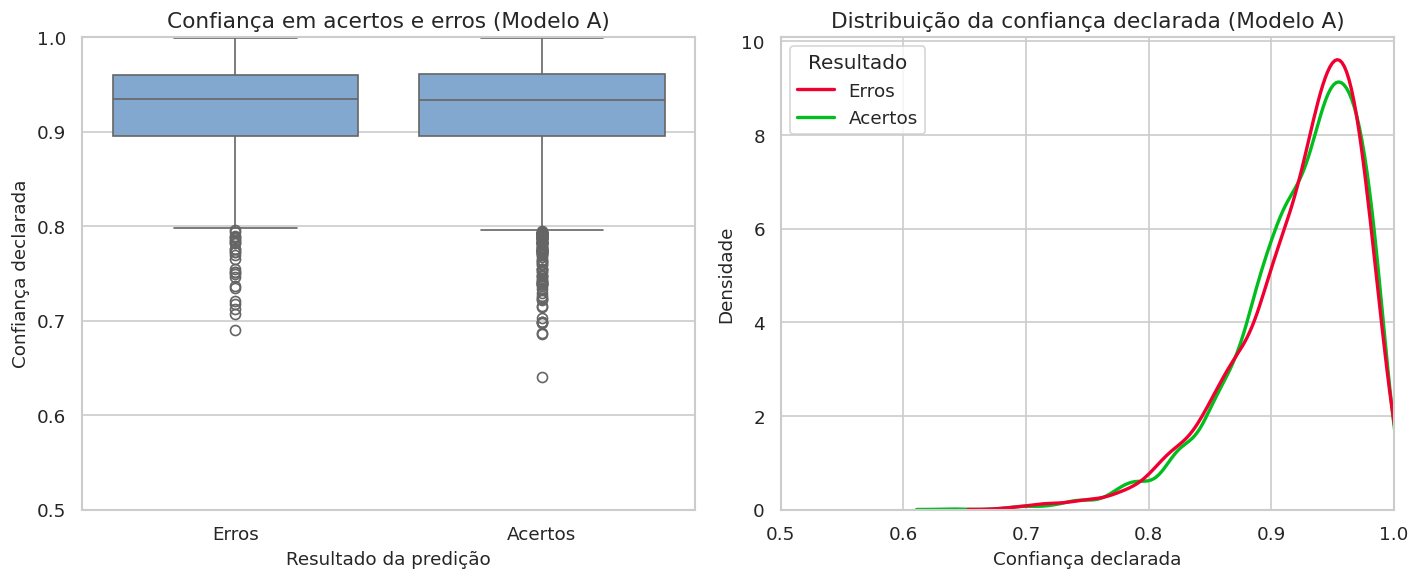

In [12]:
# Resume a confiança declarada separando predições corretas e incorretas
tabela_confianca_acerto = (
    df.groupby("acerto_modelo_a")
    .agg(
        n=("id_chamado", "count"),
        confianca_media=("conf_modelo_a", "mean"),
        confianca_mediana=("conf_modelo_a", "median"),
        confianca_p10=("conf_modelo_a", lambda x: x.quantile(0.10)),
        confianca_p90=("conf_modelo_a", lambda x: x.quantile(0.90))).reset_index()
)

tabela_confianca_acerto["resultado"] = tabela_confianca_acerto["acerto_modelo_a"].map({
    True: "Acertos",
    False: "Erros"
})
display(tabela_confianca_acerto)
save_table(tabela_confianca_acerto, tab_dir, "06_confianca_por_acerto_erro_modelo_a.csv")

# Cria rótulo legível para visualização
df_confianca_plot = df.copy()
df_confianca_plot["Resultado"] = df_confianca_plot["acerto_modelo_a"].map({
    True: "Acertos",
    False: "Erros",
})

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Boxplot mostra mediana, dispersão e possíveis valores extremos de confiança
sns.boxplot(data=df_confianca_plot, x="Resultado", y="conf_modelo_a",
    order=["Erros", "Acertos"], ax=axes[0], color="#76A7DC")

axes[0].set_title("Confiança em acertos e erros (Modelo A)")
axes[0].set_xlabel("Resultado da predição")
axes[0].set_ylabel("Confiança declarada")
axes[0].set_ylim(0.5, 1)

# Curvas de densidade comparam a distribuição completa da confiança em erros e acertos.
sns.kdeplot(
    data=df_confianca_plot, x="conf_modelo_a",
    hue="Resultado", hue_order=["Erros", "Acertos"],
    palette=["#F00031", "#00BE1D"], common_norm=False,
    fill=False, linewidth=2, ax=axes[1])

axes[1].set_title("Distribuição da confiança declarada (Modelo A)")
axes[1].set_xlabel("Confiança declarada")
axes[1].set_ylabel("Densidade")
axes[1].set_xlim(0.5, 1)
fig.tight_layout()
save_figure(fig, fig_dir, "06_confianca_acertos_erros_modelo_a")
plt.show()


**<u>Resultados</u>:**

- O Modelo A errou **1.136 chamados** e acertou **3.864**. A confiança média é praticamente igual nos dois grupos: **0,922631** nos erros e **0,922826** nos acertos.

- A mediana de `conf_modelo_a` também é quase indistinguível: **0,935** nos erros contra **0,933** nos acertos.

- Os quantis de 10% e 90% são muito próximos entre erros e acertos: nos erros, **0,851** e **0,976**; nos acertos, **0,854** e **0,979**.

⟹ Isso sugere que `conf_modelo_a` <u>não separa bem casos confiáveis de casos arriscados</u>. Usar essa confiança como gatilho automático seria frágil.



In [13]:
# Calcula a tabela de calibração por faixas e o erro esperado de calibração aproximado.
tabela_calibracao_a, ece_a = tabela_calibracao(df)
print(f"Erro esperado de calibração aproximado (ECE): {ece_a:.4f}")

Erro esperado de calibração aproximado (ECE): 0.1517



**<u>Resultado</u>:**

- O erro esperado de calibração (ECE) aproximado é **0,15**. Há um desvio médio ponderado de cerca de **15,2 pontos percentuais** entre confiança média declarada e acurácia observada nas faixas de confiança.

⟹  Como a confiança média fica em torno de **0,92** tanto para erros quanto para acertos, esse ECE reforça a hipótese de superconfiança do Modelo A.



#### **1.4 Curva de Calibração Aproximada**

**Objetivo:** comparar `conf_modelo_a` média com a acurácia observada em cada faixa de confiança.

**Metodologia:** construímos uma curva de calibração aproximada para verificar se a confiança declarada pelo modelo corresponde, na prática, à proporção real de acertos.

- `faixa_confianca_a`: é uma versão categorizada da variável `[conf_modelo_a]`. Em vez de analisar cada valor individual de confiança, agrupamos os chamados em intervalos, por exemplo, faixas como confiança entre 0,70 e 0,80, entre 0,80 e 0,90, e assim por diante. Isso torna a análise mais estável e interpretável.

Procedimento:
1. Os chamados são agrupados por `[faixa_confianca_a]`, isto é, por intervalos de confiança declarada pelo Modelo A.
2. Para cada faixa, calculamos a confiança média declarada, usando a confiança declarada pelo modelo `[conf_modelo_a]`.
3. Para essa mesma faixa, calculamos a acurácia observada, isto é, a proporção de chamados em que `[pred_modelo_a]` foi igual a `[categoria_real]`, registrada em `[acerto_modelo_a]`.
4. Cada ponto do gráfico representa uma faixa de confiança. A linha diagonal representa calibração perfeita.

- Pontos abaixo da diagonal indicam excesso de confiança e pontos acima da diagonal indicam subconfiança.

**Importância:** um modelo pode ter boa acurácia, mas ainda ser mal calibrado. É relevante, pois a confiança costuma orientar automação e priorização operacional.

---

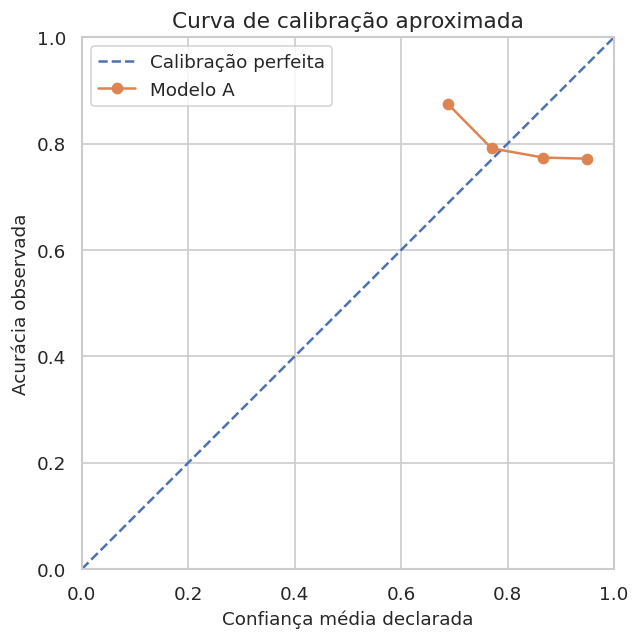

In [14]:
# Plota confiança média contra acurácia observada por faixa.
fig, ax = plt.subplots(figsize=(5.5, 5.5))
# Linha de referência: pontos sobre a diagonal estariam perfeitamente calibrados.
ax.plot([0, 1], [0, 1], linestyle="--", label="Calibração perfeita")

# Pontos do Modelo A por faixa de confiança.
ax.plot(tabela_calibracao_a["confianca_media"], tabela_calibracao_a["acuracia_observada"],
    marker="o", label="Modelo A")

ax.set_title("Curva de calibração aproximada")
ax.set_xlabel("Confiança média declarada")
ax.set_ylabel("Acurácia observada")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.legend()
save_figure(fig, fig_dir, "06_curva_calibracao_modelo_a")
plt.show()


**<u>Resultados</u>:**

- A curva do Modelo A fica abaixo da diagonal nas faixas de maior confiança, indicando que a `conf_modelo_a` média é maior do que a acurácia observada.

- Há pontos com confiança média próxima de **0,90–0,95**, mas acurácia observada em torno de **0,77–0,79**. Esse padrão é típico de <u>modelo superconfiante</u>.

⟹ A confiança declarada precisa ser calibrada ou tratada com cautela antes de ser usada para decidir quais chamados podem ser encaminhados automaticamente.


---
---
### **2. <u>Onde</u> o Modelo Falha?**
---
---

#### **2.1 Matriz de Confusão**

**Objetivo:** identificar quais pares `categoria_real` → `pred_modelo_a` concentram os erros do Modelo A.

**Metodologia:** a matriz absoluta conta chamados por par real/predito; a matriz percentual normalizada por linha mostra, dentro de cada `categoria_real`, qual fração foi atribuída a cada classe prevista. A diagonal representa acertos.

**Importância:** a matriz de confusão transforma a taxa de erro em problemas operacionais concretos. Confundir `esgoto_vazamento` com `buraco_via`, por exemplo, pode direcionar o chamado para equipe, prazo ou prioridade errada.

---

In [15]:
# Funções para montar e visualizar a matriz de confusão do Modelo A.
def matriz_confusao_tabelas(df: pd.DataFrame, labels: Sequence[Any]) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """Calcula matriz de confusão absoluta e percentual por categoria real."""
    matriz_abs = pd.DataFrame(confusion_matrix(df["categoria_real"], df["pred_modelo_a"],
                                             labels=labels),index=labels,columns=labels)
    # Normaliza por linha para interpretar cada categoria real separadamente.
    matriz_pct_linha = matriz_abs.div(
        matriz_abs.sum(axis=1).replace(0, np.nan),
        axis=0) * 100

    return matriz_abs, matriz_pct_linha


def plotar_matriz_confusao(matriz_abs: pd.DataFrame, matriz_pct: pd.DataFrame, nome_arquivo: str) -> None:
    """Plota matriz de confusão com contagem absoluta e percentual por linha."""
    matriz_abs_plot = matriz_abs.copy()
    matriz_pct_plot = matriz_pct.copy()

    # Converte nomes técnicos em rótulos mais legíveis para o gráfico.
    matriz_abs_plot.index = [pretty_label(x) for x in matriz_abs_plot.index]
    matriz_abs_plot.columns = [pretty_label(x) for x in matriz_abs_plot.columns]
    matriz_pct_plot.index = matriz_abs_plot.index
    matriz_pct_plot.columns = matriz_abs_plot.columns

    fig, ax = plt.subplots(figsize=(8, 7))
    # A cor representa o percentual dentro de cada categoria real.
    sns.heatmap(matriz_pct_plot,
        cmap="Blues", linewidths=0.5, cbar=True,
        annot=False, ax=ax, vmin=0, vmax=100)

    # Escreve contagem absoluta e percentual em cada célula.
    for i in range(matriz_abs_plot.shape[0]):
        for j in range(matriz_abs_plot.shape[1]):
            valor_abs = matriz_abs_plot.iloc[i, j]
            valor_pct = matriz_pct_plot.iloc[i, j]

            cor = "white" if valor_pct >= 50 else "#222222"            
            ax.text(j + 0.5, i + 0.42,
                f"{valor_abs:.0f}", ha="center", va="center",
                fontsize=10, color=cor)
            
            ax.text(j + 0.5, i + 0.65,
                f"({valor_pct:.1f}%)",
                ha="center", va="center",
                fontsize=8, color=cor)

    ax.set_title("Matriz de confusão do Modelo A")
    ax.set_xlabel("Categoria prevista")
    ax.set_ylabel("Categoria real")
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    fig.tight_layout()
    save_figure(fig, fig_dir, nome_arquivo)
    plt.show()

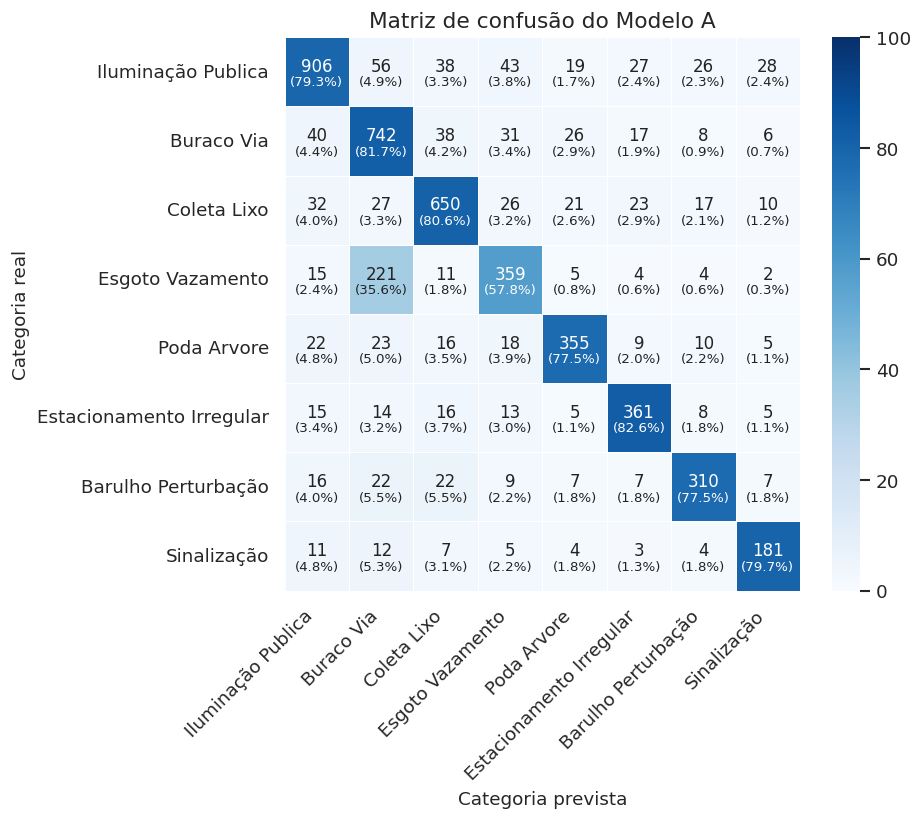

In [16]:
# Calcula, exporta e visualiza a matriz de confusão.
matriz_abs_a, matriz_pct_a = matriz_confusao_tabelas(df, classes)

save_table(matriz_abs_a, tab_dir, "05_matriz_confusao_modelo_a_absoluta", index=True)
save_table(matriz_pct_a, tab_dir, "05_matriz_confusao_modelo_a_percentual_linha", index=True)

plotar_matriz_confusao(matriz_abs_a, matriz_pct_a, "05_matriz_confusao_modelo_a")


**<u>Resultados</u>:**

- O principal modo de falha é `esgoto_vazamento` previsto como `buraco_via`: são **221 chamados**, equivalentes a **35,6%** dos casos reais de `esgoto_vazamento`.

- A diagonal confirma os recalls por categoria: `esgoto_vazamento` acerta apenas **359 de 621 chamados (57,8%)**, enquanto `buraco_via` acerta **742 de 908 (81,7%)** e `coleta_lixo` acerta **650 de 806 (80,6%)**.

- `iluminacao_publica` tem **906 acertos de 1.143 (79,3%)**, mas seus erros se espalham por várias classes, como `buraco_via` (**56**), `esgoto_vazamento` (**43**) e `coleta_lixo` (**38**).

- O padrão sugere uma fronteira lexical/operacional difícil entre problemas de via pública e vazamento/esgoto. Esse erro tem impacto prático relevante pois poderia, por exemplo, encaminhar um problema sanitário para uma fila de manutenção viária.


#### **2.2 Principais Erros de Alta Confiança**

**Objetivo:** identificar erros nos quais o Modelo A errou mesmo declarando `conf_modelo_a` elevada.

**Metodologia:** filtramos casos com `erro_modelo_a` verdadeiro e `conf_modelo_a` $\geq 0,8$. Depois agregamos os pares `categoria_real` → `pred_modelo_a` para encontrar os modos de falha mais recorrentes.

**Importância:** erros de alta confiança são especialmente críticos em produção, porque têm maior chance de passar sem revisão humana caso a confiança seja usada como critério de automação.

---

In [17]:
# Define limiar para classificar erros como de alta confiança.
limiar_alta_confianca = 0.8

# Mantém apenas chamados incorretos em que o Modelo A declarou confiança alta.
df_erros_alta_confianca = df[(df["erro_modelo_a"]) & (df["conf_modelo_a"] >= limiar_alta_confianca)].copy()

# Agrega os erros de alta confiança por par real/predito.
tabela_erros_alta_confianca = (
    df_erros_alta_confianca
    .groupby(["categoria_real", "pred_modelo_a"])
    .agg(
        n=("id_chamado", "count"),
        confianca_media=("conf_modelo_a", "mean"),
        confianca_mediana=("conf_modelo_a", "median"),
    )
    .reset_index()
    .sort_values("n", ascending=False)
)

# Cria rótulos formatados apenas para visualização.
tabela_erros_alta_confianca["categoria_real_pt"] = tabela_erros_alta_confianca["categoria_real"].map(pretty_label)
tabela_erros_alta_confianca["categoria_prevista_pt"] = tabela_erros_alta_confianca["pred_modelo_a"].map(pretty_label)

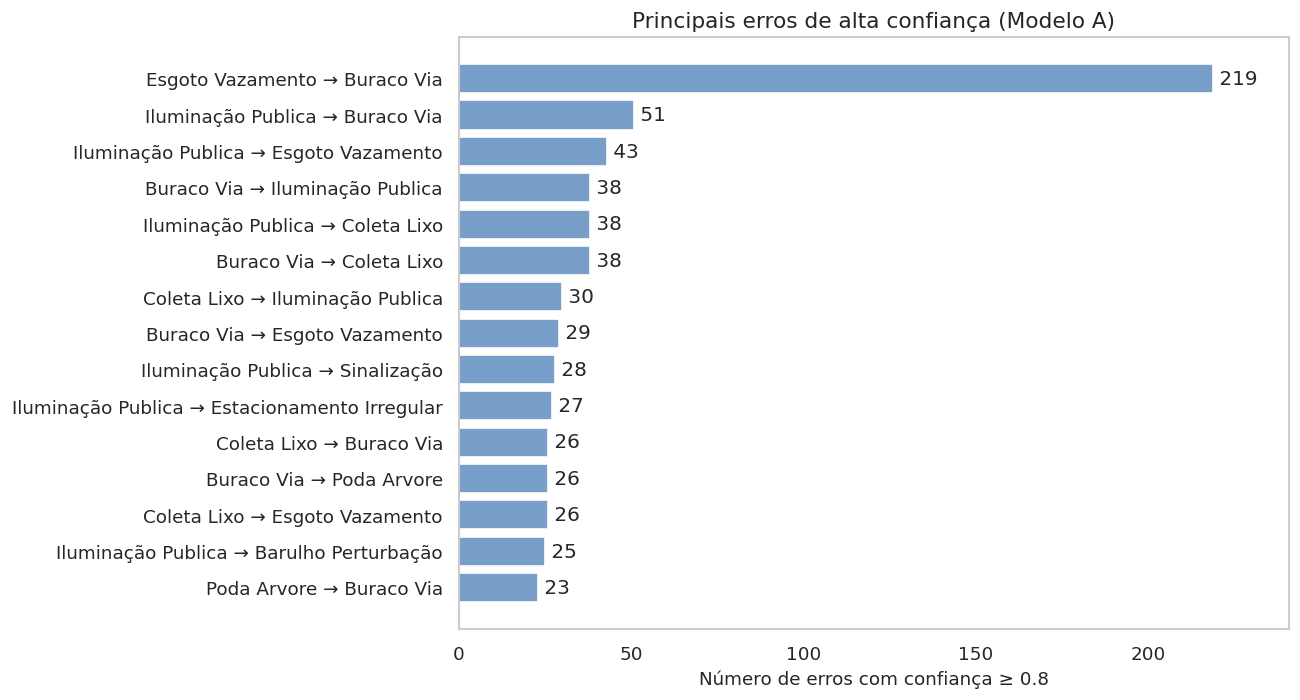

In [18]:
# Plota os pares de confusão mais frequentes entre erros de alta confiança.
fig, ax = plt.subplots(figsize=(11, 6))
dados_plot = tabela_erros_alta_confianca.head(15).copy()
dados_plot["par_confusao"] = (
    dados_plot["categoria_real_pt"] + " → " + dados_plot["categoria_prevista_pt"]
)

dados_plot = dados_plot.sort_values("n", ascending=True)
valores = dados_plot["n"]

ax.grid(False)
ax.set_xlim(0, valores.max() * 1.1)
ax.barh(dados_plot["par_confusao"], valores, color="#779FC9")
ax.set_title("Principais erros de alta confiança (Modelo A)")
ax.set_xlabel(f"Número de erros com confiança ≥ {limiar_alta_confianca}")
ax.set_ylabel("")

# Adiciona o número absoluto de erros ao fim de cada barra.
for i, valor in enumerate(dados_plot["n"]):
    ax.text(valor, i, f" {valor}", va="center")

save_figure(fig, fig_dir, "06_principais_erros_alta_confianca_modelo_a")
plt.show()


**<u>Resultados</u>:**

- Entre erros de alta confiança, o par dominante é `esgoto_vazamento` → `buraco_via`, com **219 erros**. Esse valor é **MUITO** acima do segundo maior par.

- O segundo modo de falha é `iluminacao_publica` → `buraco_via`, com **51 erros**, seguido por `iluminacao_publica` → `esgoto_vazamento`, com **43 erros**.

- Também aparecem confusões recorrentes envolvendo `buraco_via` e `coleta_lixo`, ambas com **38 erros** em pares específicos.

- Como esses erros ocorrem com `conf_modelo_a` ≥ **0,8**, eles são mais preocupantes que erros de baixa confiança. A confiança alta não está protegendo contra as principais falhas.


#### **2.3 Testes de Homogeneidade dos Erros**

**Objetivo:** verificar se `acerto_modelo_a` tem distribuição semelhante entre subgrupos como `categoria_real`, `canal`, `bairro`, `faixa_tamanho_texto`, `bool_texto_curto` e `faixa_confianca_a`.

**Metodologia:** aplicamos testes qui-quadrado de independência. O <u>teste qui-quadrado</u> verifica se duas variáveis categóricas parecem estar associadas ou se as diferenças observadas entre grupos podem ser explicadas apenas por variação aleatória. Neste caso, ele serve para avaliar se a taxa de acerto/erro do modelo muda de forma relevante entre grupos.

- $H_0$ (Hipótese Nula): `acerto_modelo_a` é independente da variável avaliada.
- $H_1$ (Hipótese Alternativa): `acerto_modelo_a` depende da variável avaliada $\Rightarrow$ Há evidência de que a taxa de acerto/erro varia entre os grupos.

A estatística do teste é $\chi^2=\sum (O-E)^2/E$, comparando frequências observadas $O$ e esperadas $E$ sob independência.\
P-valores pequenos indicam evidência contra homogeneidade da taxa de erro entre os grupos.

**Importância:** mesmo com boa métrica média, um modelo em produção pode ser inadequado se falha sistematicamente em certos tipos de chamados.

---

In [19]:
# Função para testar associação entre acerto/erro e uma variável categórica.
def teste_homogeneidade_erro(df: pd.DataFrame, coluna: str) -> Dict[str, Union[str, float, int]]:
    """Aplica teste qui-quadrado entre [acerto_modelo_a] e uma coluna categórica.
    Retorna estatística, p-valor, graus de liberdade e tamanho da amostra.
    """
    tabela = pd.crosstab(df[coluna], df["acerto_modelo_a"])

    # O teste requer pelo menos duas linhas e duas colunas na tabela de contingência.
    if tabela.shape[0] < 2 or tabela.shape[1] < 2:
        return {"Variável": coluna, "Qui-Quadrado": np.nan,
                "P-Valor": np.nan, "Graus de Liberdade": np.nan, "n": len(df)}

    chi2, p, gl, _ = chi2_contingency(tabela)

    return {"Variável": coluna, "Qui-Quadrado": chi2,
        "P-Valor": p, "Graus de Liberdade": gl, "n": len(df)}


# Aplica o teste para dimensões relevantes de categoria, canal, território, texto e confiança.
tabela_testes_homogeneidade = pd.DataFrame([
    teste_homogeneidade_erro(df, "categoria_real"),
    teste_homogeneidade_erro(df, "canal"),
    teste_homogeneidade_erro(df, "bairro"),
    teste_homogeneidade_erro(df, "faixa_tamanho_texto"),
    teste_homogeneidade_erro(df, "bool_texto_curto"),
    teste_homogeneidade_erro(df, "faixa_confianca_a"),
])

display(tabela_testes_homogeneidade)
save_table(tabela_testes_homogeneidade, tab_dir, "06_testes_homogeneidade_erro_modelo_a.csv")

,Variável,Qui-Quadrado,P-Valor,Graus de Liberdade,n
0,categoria_real,159.896614,3.372557e-31,7,5000
1,canal,1.999563,3.679598e-01,2,5000
2,bairro,8.432123,8.656215e-01,14,5000
3,faixa_tamanho_texto,349.249771,2.168314e-75,3,5000
4,bool_texto_curto,11.288479,7.798956e-04,1,5000
5,faixa_confianca_a,0.765272,8.577541e-01,3,5000


PosixPath('../results/tables/auditoria_modelo_a/06_testes_homogeneidade_erro_modelo_a.csv.csv')


**<u>Resultados</u>:**

- Há evidência estatística muito forte de heterogeneidade dos erros por `categoria_real`:
    - Qui-quadrado **159,90**;
    - P-valor **3,37e-31**.
    
⟹ Portanto, rejeitamos a hipótese nula de que a taxa de erro é homogênea entre categorias.

- `faixa_tamanho_texto` também apresenta associação forte com `acerto_modelo_a`:
    - Qui-quadrado **349,25**; 
    - P-valor **2,17e-75**. 
    
⟹ O tamanho do texto é um fator importante para o desempenho.


- `bool_texto_curto` é significativo com p-valor **0,00078**.

⟹ Isso reforça que textos muito curtos têm comportamento diferente.

- Não há evidência estatística relevante de heterogeneidade por `canal` (p-valor **0,368**), `bairro` (p-valor **0,866**) ou `faixa_confianca_a` (p-valor **0,858**). 

⟹ Nessas variáveis, os dados observados não sustentam rejeitar homogeneidade da taxa de acerto.

---

#### **2.4 Investigando Fatores Associados ao Erro com Modelo Auxiliar**

**Objetivo:** estimar, em uma análise multivariada, quais fatores estão associados à chance de [erro_modelo_a].

**Metodologia:** Ajustamos uma regressão logística binomial com resposta `erro_int`.
$$
\text{erro\_int}_i =
\begin{cases}
1, & \text{se } [\text{pred\_modelo\_a}]_i \neq [\text{categoria\_real}]_i \\
0, & \text{se } [\text{pred\_modelo\_a}]_i = [\text{categoria\_real}]_i
\end{cases}
$$

O modelo assume:

$$\text{logit}(p_i) = \text{logit}(P(\text{erro}_i =1))=\beta_0+\beta^\top X$$

Os coeficientes são reportados como razão de chances, ou *Odds Ratio* (razão de chances), calculada por $\exp(\beta)$. Intervalos de confiança de 95% são calculados a partir dos erros-padrão robustos HC3, reduzindo sensibilidade a heterocedasticidade.

**Interpretação:**

$$\begin{cases} 
\text{Maior chance de erro em relação ao grupo de referência} & \text{se Odds Ratio} > 1 \\
\text{Menor chance //} &  \text{se Odds Ratio} < 1
\end{cases}
$$ 

 O p-valor testa a hipótese nula de coeficiente $(\beta)$ igual a zero, isto é, razão de chances igual a 1.


In [20]:
# Prepara variável resposta binária para regressão logística: 1 = erro, 0 = acerto.
df_modelo_erro = df.copy()
df_modelo_erro["erro_int"] = df_modelo_erro["erro_modelo_a"].astype(int)

# Ajusta modelo binomial para estimar fatores associados à ocorrência de erro.
modelo_erro = smf.glm(
    formula="erro_int ~ C(categoria_real) + C(canal) + C(faixa_tamanho_texto) + log_palavras",
    data=df_modelo_erro,
    family=sm.families.Binomial(),
).fit(cov_type="HC3")

# Converte coeficientes logísticos para odds ratios, mais interpretáveis para diagnóstico.
tabela_odds_erro = pd.DataFrame({
    "Variável": modelo_erro.params.index,
    "Coeficiente": modelo_erro.params.values,
    "Odds Ratio": np.exp(modelo_erro.params.values),
    "IC Inf. (95%)": np.exp(modelo_erro.conf_int()[0].values),
    "IC Sup. (95%)": np.exp(modelo_erro.conf_int()[1].values),
    "P-Valor": modelo_erro.pvalues.values,
})

# Remove o intercepto e ordena pelos menores p-valores para destacar associações mais fortes.
tabela_odds_erro = (
    tabela_odds_erro[tabela_odds_erro["Variável"] != "Intercept"]
    .sort_values("P-Valor")
)

display(tabela_odds_erro)
save_table(tabela_odds_erro, tab_dir, "06_regressao_logistica_fatores_associados_erro_modelo_a")

,Variável,Coeficiente,Odds Ratio,IC Inf. (95%),IC Sup. (95%),P-Valor
3,C(categoria_real)[T.esgoto_vazamento],1.053106,2.866540,2.109426,3.895396,1.695582e-11
10,C(faixa_tamanho_texto)[T.Textos médio-curtos],-0.974148,0.377514,0.153899,0.926043,3.335448e-02
11,C(faixa_tamanho_texto)[T.Textos médio-longos],-1.014998,0.362403,0.136176,0.964456,4.210981e-02
4,C(categoria_real)[T.estacionamento_irregular],-0.358806,0.698510,0.490592,0.994545,4.655745e-02
1,C(categoria_real)[T.buraco_via],-0.307145,0.735544,0.542550,0.997190,4.791861e-02
12,C(faixa_tamanho_texto)[T.Textos mais longos],-1.017886,0.361358,0.124784,1.046443,6.061630e-02
9,C(canal)[T.telefone_1746],-0.147930,0.862491,0.737422,1.008774,6.421557e-02
2,C(categoria_real)[T.coleta_lixo],-0.225777,0.797896,0.584871,1.088511,1.542254e-01
8,C(canal)[T.portal_web],-0.087208,0.916486,0.753241,1.115111,3.835653e-01
7,C(categoria_real)[T.sinalizacao],-0.185249,0.830897,0.545171,1.266373,3.889099e-01


PosixPath('../results/tables/auditoria_modelo_a/06_regressao_logistica_fatores_associados_erro_modelo_a.csv')


**<u>Resultados</u>:**

- Controlando por `canal`, `faixa_tamanho_texto` e `log_palavras`, `esgoto_vazamento` tem:
    - Odds Ratio de erro **2,87** com IC 95% **[2,11; 3,90]**;
    - P-valor **1,70e-11**.
    
⟹ O intervalo não contém 1 e o p-valor é muito pequeno, então há forte evidência de maior risco de erro nessa categoria em relação ao grupo de referência.

- `Textos médio-curtos` têm:
    - Odds Ratio **0,38** com IC 95% **[0,15; 0,93]**;
    - P-valor **0,033**.
    
- `Textos médio-longos` têm:
    - Odds Ratio **0,36** com IC 95% **`0,14; 0,96`**;
    - P-valor **0,042**. 
    
⟹ Isso indica menor chance de erro em relação aos textos mais curtos.

- `estacionamento_irregular` apresenta:
    - Odds Ratio **0,70** com IC 95% **[0,49; 0,99]**;
    - P-valor **0,047**; 
    
- `buraco_via` apresenta:
    - Odds Ratio **0,74** com IC 95% **[0,54; 1,00]**;
    - P-valor **0,048**. 
    
⟹  A evidência é mais fraca, mas sugere menor chance de erro que o grupo de referência.

- `canal` não aparece como fator robusto: `telefone_1746` tem p-valor **0,064** e `portal_web` tem p-valor **0,384**. 

⟹ Assim, a evidência de falha sistemática por canal é limitada.

- `log_palavras` tem p-valor **0,454**, sem evidência estatística de associação adicional depois de controlar pelas faixas de tamanho.\
A variável contínua parece acrescentar pouco além de `faixa_tamanho_texto`.



---
---
### **3. Síntese dos Achados mais Relevantes**

1. **O desempenho global do Modelo A é razoável, mas não suficiente para encerrar a auditoria.**  
   A acurácia é **0,7728** e o F1 Macro é **0,7704**, ambos com IC 95% estreitos. Isso indica estabilidade global, mas não garante desempenho homogêneo entre categorias.

2. **A maior fragilidade está em `esgoto_vazamento`.**  
   Essa categoria tem `recall` de apenas **0,5781**, `taxa_erro` de **0,4219** e responde por **23,1%** dos erros totais. Na matriz de confusão, **221 de 621** chamados reais de `esgoto_vazamento` foram previstos como `buraco_via`.

3. **A confiança declarada pelo Modelo A está mal calibrada.**  
   `conf_modelo_a` média é praticamente igual em erros (**0,922631**) e acertos (**0,922826**), e o ECE aproximado é **0,1517**. Portanto, a confiança não deve ser usada isoladamente como critério de encaminhamento automático.

4. **Os erros não são homogêneos.**  
   Os testes qui-quadrado indicam associação forte entre `erro_modelo_a` e `categoria_real` (p-valor **3,37e-31**) e entre `erro_modelo_a` e `faixa_tamanho_texto` (p-valor **2,17e-75**). Não há evidência relevante de heterogeneidade por `canal` ou `bairro`.

5. **O principal risco operacional é a combinação de erro recorrente com alta confiança.**  
   O par `esgoto_vazamento` → `buraco_via` concentra **219 erros de alta confiança**, sugerindo que o Modelo A pode encaminhar muitos chamados de saneamento para fluxo incorreto sem sinalizar incerteza.

⇒ O <u>Modelo A</u> tem desempenho global estável, mas apresenta falhas relevantes, especialmente em `esgoto_vazamento` e em textos mais curtos.\
A troca pelo Modelo B só deve ser recomendada se ele melhorar esses pontos críticos sem degradar categorias já estáveis.

